# Muhammad Rizqi Nurrohmat - 0110224001
# Machine Learning - Pertemuan 9 - Algoritma Naive Bayes

## *Analisis Klasifikasi Kanker Payudara Menggunakan Algoritma Naive Bayes*

1. Menerapkan algoritma Naive Bayes sebagai metode klasifikasi pada dataset Breast Cancer Wisconsin.
2. Mengidentifikasi perbedaan antara sampel kanker payudara berjenis Malignant dan Benign berdasarkan fitur-fitur numerik dalam dataset.
3. Mengukur performa model melalui evaluasi akurasi, confusion matrix, classification report, dan cross-validation.
4. Memahami tahapan preprocessing data, mulai dari pembersihan dataset, encoding label, normalisasi fitur, hingga pemisahan data training dan testing.
5. Menilai apakah Naive Bayes merupakan algoritma yang efektif untuk deteksi dini kanker payudara berdasarkan data yang tersedia.

1. Import Library 

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

2. load Dataset

In [ ]:
df = pd.read_csv("../data/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


3. Cek Struktur dan Missing Value

In [24]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

4. Hapus Kolom Tidak Diperlukan

In [25]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

5. Statistik Deskriptif

In [26]:
df.describe()
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

6. Visualisasi Data

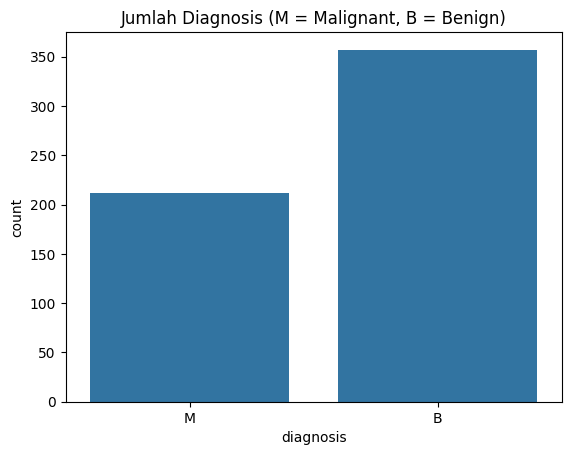

In [27]:
# 6.1 Countplot Diagnosisi
sns.countplot(x=df['diagnosis'])
plt.title("Jumlah Diagnosis (M = Malignant, B = Benign)")
plt.show()

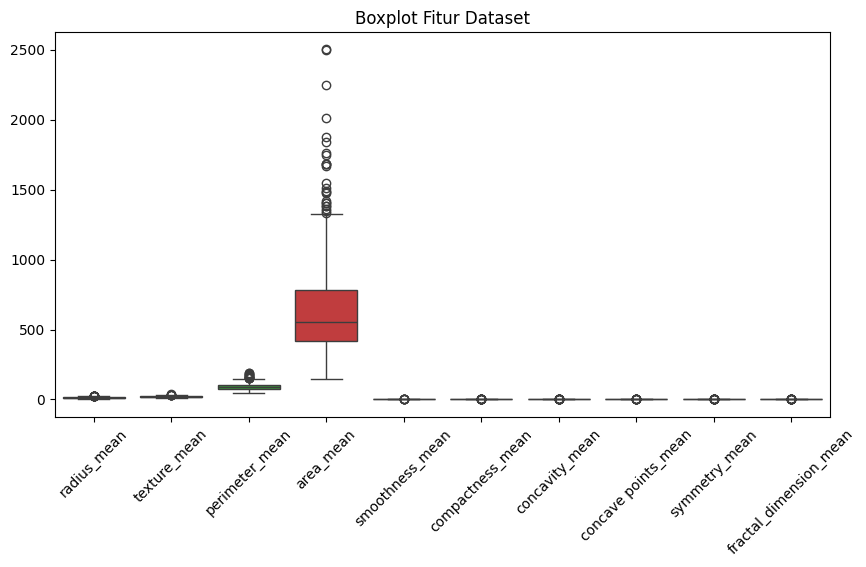

In [28]:
# 6.2 Boxplot Beberapa Fitur
plt.figure(figsize=(10,5))
sns.boxplot(data=df.iloc[:, 1:11])
plt.xticks(rotation=45)
plt.title("Boxplot Fitur Dataset")
plt.show()

7. Mengubah label diagnosis menjadi angka (encoding)

In [29]:
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

8. Memisahkan Data Fitur (X) dan Label (Y)

In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

9. Membagi Data menjadi Training Set dan Testing Set

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

10. Normalisasi Data dengan StandardScaler

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

11. Membuat dan Melatih Model Naive Bayes

In [33]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


12. Melakukan Prediksi

In [34]:
train_pred = nb.predict(X_train_scaled)
test_pred = nb.predict(X_test_scaled)

13. Mengukur Akurasi Model

In [35]:
print("Akurasi Training :", accuracy_score(y_train, train_pred))
print("Akurasi Testing  :", accuracy_score(y_test, test_pred))

Akurasi Training : 0.9362637362637363
Akurasi Testing  : 0.9649122807017544


14. Menampilkan Confusion Matrix

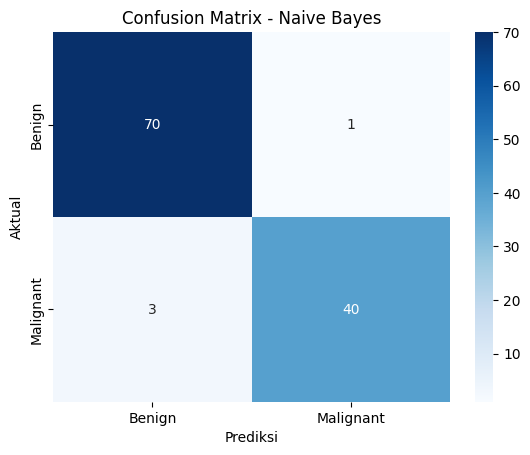

In [36]:
cm = confusion_matrix(y_test, test_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

15. Menampilkan Classification Report

In [37]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



16. Evaluasi Model Menggunakan Cross Validation (5-Fold)

In [38]:
cv_scores = cross_val_score(nb, X, y, cv=5, scoring='accuracy')

print("Skor Cross Validation:", cv_scores)
print("Rata-rata Akurasi    :", cv_scores.mean())
print("Standar Deviasi      :", cv_scores.std())

Skor Cross Validation: [0.92105263 0.92105263 0.94736842 0.94736842 0.95575221]
Rata-rata Akurasi    : 0.9385188635305075
Standar Deviasi      : 0.014585994424363306
